# Primjena algoritma roja čestica za određivanje direktnog upravljanja

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01
T = 5.0


In [ ]:
def step_ref(t):
    return 1.0

def disturbance_none(t):
    return 0.0

# poremećaj 2.0–2.2 s
def disturbance_pulse(t, amp=1.0, t1=2.0, t2=2.2):
    return amp if (t1 <= t <= t2) else 0.0


In [ ]:
def simulate_direct_u(u_vec, ref_func=step_ref, disturbance_func=disturbance_none,
                      dt=0.01, T=5.0):
    """
    u_vec: (N,) piecewise-constant upravljanje
    """
    N = len(u_vec)
    steps = int(T / dt)
    seg_len = T / N

    y = 0.0
    ydot = 0.0

    ts = np.linspace(0.0, T, steps, endpoint=False)
    ys = np.zeros(steps)
    us = np.zeros(steps)
    rs = np.zeros(steps)

    for k, t in enumerate(ts):
        seg_idx = min(int(t / seg_len), N - 1)
        u = float(u_vec[seg_idx])
        d = float(disturbance_func(t))
        r = float(ref_func(t))

        # y'' = -10 y' -20 y + (u + d)
        yddot = -10.0 * ydot - 20.0 * y + (u + d)

        # Euler integracija
        ydot += yddot * dt
        y += ydot * dt

        ys[k] = y
        us[k] = u
        rs[k] = r

    return ts, ys, us, rs


In [ ]:
def ise_direct(u_vec, ref_func=step_ref, disturbance_func=disturbance_none,
               dt=0.01, T=5.0):
    ts, ys, us, rs = simulate_direct_u(u_vec, ref_func, disturbance_func, dt, T)
    e = rs - ys
    J = np.sum(e * e) * dt  # ISE

    # sigurnosni penal
    if not np.isfinite(J) or np.max(np.abs(ys)) > 1e6:
        return 1e12

    return float(J)


In [ ]:
def pso_direct_u(num_particles=20, num_iterations=50, N=25,
                 umin=-5.0, umax=5.0,
                 w=0.7, c1=1.5, c2=1.5,
                 ref_func=step_ref, disturbance_func=disturbance_none,
                 dt=0.01, T=5.0, seed=123):

    rng = np.random.default_rng(seed)

    bounds = np.array([[umin, umax]] * N, dtype=float)

    # inicijalizacija
    positions = rng.uniform(bounds[:, 0], bounds[:, 1], size=(num_particles, N))
    velocities = rng.uniform(-1.0, 1.0, size=(num_particles, N))

    pbest_positions = positions.copy()
    pbest_scores = np.array([ise_direct(p, ref_func, disturbance_func, dt, T)
                             for p in positions], dtype=float)

    gbest_idx = int(np.argmin(pbest_scores))
    gbest_position = pbest_positions[gbest_idx].copy()
    gbest_score = float(pbest_scores[gbest_idx])

    best_scores_history = []

    for iteration in range(num_iterations):
        for i in range(num_particles):
            # vektorski r1,r2 (preporučeno)
            r1 = rng.random(N)
            r2 = rng.random(N)

            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (pbest_positions[i] - positions[i])
                + c2 * r2 * (gbest_position - positions[i])
            )

            positions[i] += velocities[i]
            positions[i] = np.clip(positions[i], bounds[:, 0], bounds[:, 1])

            score = ise_direct(positions[i], ref_func, disturbance_func, dt, T)

            if score < pbest_scores[i]:
                pbest_scores[i] = score
                pbest_positions[i] = positions[i].copy()

                if score < gbest_score:
                    gbest_score = score
                    gbest_position = positions[i].copy()

        best_scores_history.append(gbest_score)

    return gbest_position, gbest_score, np.array(best_scores_history)


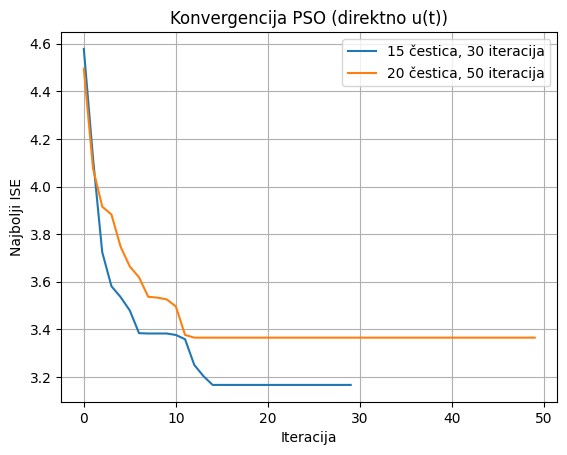

Direct PSO small best ISE: 3.1661632332969614
Direct PSO large best ISE: 3.364890957159958


In [ ]:
N = 25
umin, umax = -5, 5

# mala konfiguracija
u_small, score_small, hist_small = pso_direct_u(
    num_particles=15, num_iterations=30, N=N,
    umin=umin, umax=umax, ref_func=step_ref, disturbance_func=disturbance_none,
    dt=dt, T=T, seed=1
)

# velika konfiguracija
u_large, score_large, hist_large = pso_direct_u(
    num_particles=20, num_iterations=50, N=N,
    umin=umin, umax=umax, ref_func=step_ref, disturbance_func=disturbance_none,
    dt=dt, T=T, seed=2
)

plt.figure()
plt.plot(hist_small, label="15 čestica, 30 iteracija")
plt.plot(hist_large, label="20 čestica, 50 iteracija")
plt.xlabel("Iteracija")
plt.ylabel("Najbolji ISE")
plt.title("Konvergencija PSO (direktno u(t))")
plt.legend()
plt.grid(True)
plt.savefig("pso_direct_convergence.png", dpi=200, bbox_inches="tight")
plt.show()

print("Direct PSO small best ISE:", score_small)
print("Direct PSO large best ISE:", score_large)


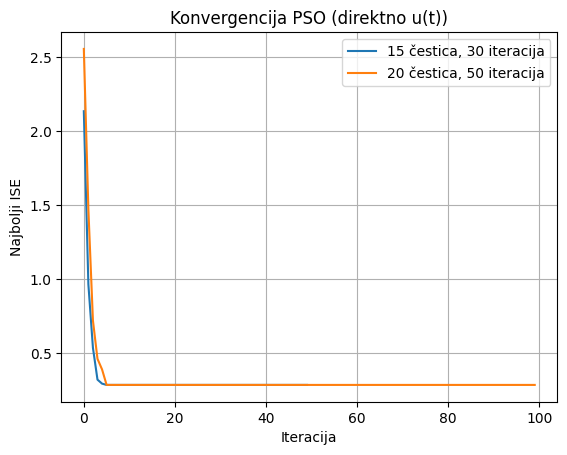

Direct PSO small best ISE: 0.287525013163926
Direct PSO large best ISE: 0.287525013163926


In [ ]:
N = 25
umin, umax = -20, 20

# mala konfiguracija
u_small, score_small, hist_small = pso_direct_u(
    num_particles=20, num_iterations=50, N=N,
    umin=umin, umax=umax, ref_func=step_ref, disturbance_func=disturbance_none,
    dt=dt, T=T, seed=1
)

# velika konfiguracija
u_large, score_large, hist_large = pso_direct_u(
    num_particles=30, num_iterations=100, N=N,
    umin=umin, umax=umax, ref_func=step_ref, disturbance_func=disturbance_none,
    dt=dt, T=T, seed=2
)

plt.figure()
plt.plot(hist_small, label="15 čestica, 30 iteracija")
plt.plot(hist_large, label="20 čestica, 50 iteracija")
plt.xlabel("Iteracija")
plt.ylabel("Najbolji ISE")
plt.title("Konvergencija PSO (direktno u(t))")
plt.legend()
plt.grid(True)
plt.savefig("pso_direct_convergence.png", dpi=200, bbox_inches="tight")
plt.show()

print("Direct PSO small best ISE:", score_small)
print("Direct PSO large best ISE:", score_large)


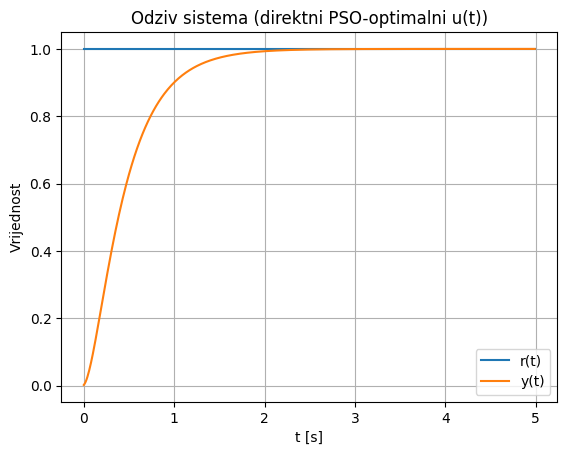

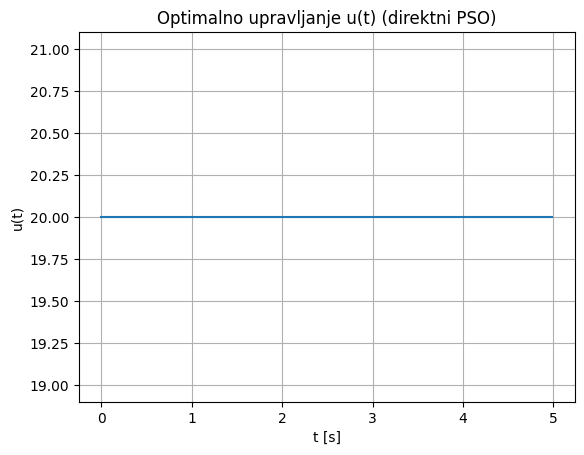

In [ ]:
ts, ys, us, rs = simulate_direct_u(u_large, step_ref, disturbance_none, dt, T)

plt.figure()
plt.plot(ts, rs, label="r(t)")
plt.plot(ts, ys, label="y(t)")
plt.xlabel("t [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv sistema (direktni PSO-optimalni u(t))")
plt.legend()
plt.grid(True)
plt.savefig("direct_response.png", dpi=200, bbox_inches="tight")
plt.show()

# bonus: prikaži optimalni u(t)
plt.figure()
plt.plot(ts, us)
plt.xlabel("t [s]")
plt.ylabel("u(t)")
plt.title("Optimalno upravljanje u(t) (direktni PSO)")
plt.grid(True)
plt.savefig("direct_u.png", dpi=200, bbox_inches="tight")
plt.show()


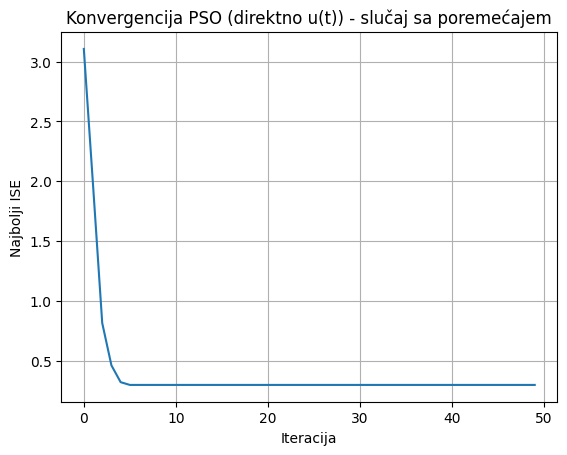

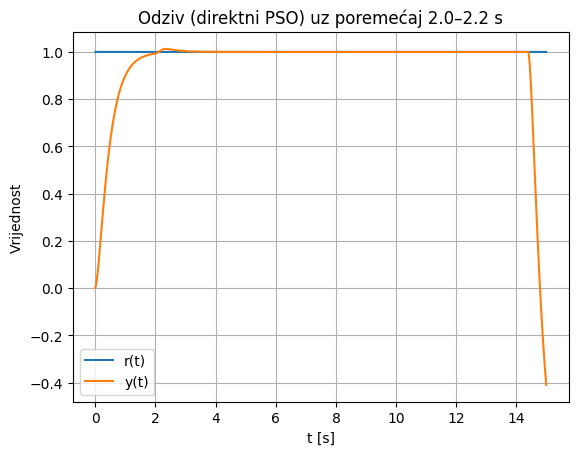

In [ ]:
def dist_case(t):
    return disturbance_pulse(t, amp=1.0, t1=2.0, t2=2.2)

u_dist, score_dist, hist_dist = pso_direct_u(
    num_particles=20, num_iterations=50, N=N,
    umin=umin, umax=umax,
    ref_func=step_ref, disturbance_func=dist_case,
    dt=dt, T=T, seed=3
)

plt.figure()
plt.plot(hist_dist)
plt.xlabel("Iteracija")
plt.ylabel("Najbolji ISE")
plt.title("Konvergencija PSO (direktno u(t)) - slučaj sa poremećajem")
plt.grid(True)
plt.savefig("pso_direct_disturbance_conv.png", dpi=200, bbox_inches="tight")
plt.show()

ts, ys, us, rs = simulate_direct_u(u_dist, step_ref, dist_case, dt, 15)

plt.figure()
plt.plot(ts, rs, label="r(t)")
plt.plot(ts, ys, label="y(t)")
plt.xlabel("t [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv (direktni PSO) uz poremećaj 2.0–2.2 s")
plt.legend()
plt.grid(True)
plt.savefig("direct_disturbance_response.png", dpi=200, bbox_inches="tight")
plt.show()


#Referentni signali r(t)

In [ ]:
def step_ref(t):
    return 1.0

def ramp_ref(t):
    return 0.5 * t

def sine_ref(t):
    return np.sin(2 * np.pi * 0.5 * t)


#PSO

In [ ]:
def run_pso(num_particles, num_iterations, bounds, r_func, simulate_func, seed=0, w=0.7, c1=1.5, c2=1.5):
    rng = np.random.default_rng(seed)

    positions = rng.uniform(bounds[:, 0], bounds[:, 1], (num_particles, 3))
    velocities = np.zeros((num_particles, 3))

    pbest_positions = positions.copy()
    pbest_scores = np.array([simulate_func(p[0], p[1], p[2], r_func) for p in positions])

    gbest_index = np.argmin(pbest_scores)
    gbest_position = pbest_positions[gbest_index].copy()
    gbest_score = float(pbest_scores[gbest_index])

    best_scores_history = []
    gbest_found_iter = 0
    vmax = np.array([10.0, 10.0, 10.0])

    for it in range(num_iterations):
        for i in range(num_particles):
            r1, r2 = rng.random(), rng.random()

            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (pbest_positions[i] - positions[i])
                + c2 * r2 * (gbest_position - positions[i])
            )

            velocities[i] = np.clip(velocities[i], -vmax, vmax)
            positions[i] += velocities[i]

            # odbijanje od zida
            for j in range(3):
                low, high = bounds[j, 0], bounds[j, 1]
                if positions[i, j] < low:
                    positions[i, j] = low + (low - positions[i, j])
                    velocities[i, j] *= -0.7
                elif positions[i, j] > high:
                    positions[i, j] = high - (positions[i, j] - high)
                    velocities[i, j] *= -0.7

            score = simulate_func(positions[i][0], positions[i][1], positions[i][2], r_func)

            if score < pbest_scores[i]:
                pbest_scores[i] = score
                pbest_positions[i] = positions[i].copy()

                if score < gbest_score:
                    gbest_score = float(score)
                    gbest_position = positions[i].copy()
                    gbest_found_iter = it

        best_scores_history.append(gbest_score)

    return gbest_position, gbest_score, best_scores_history, gbest_found_iter


#Model upravljanog sistema 1
Razmatra se linearni dinamički sistem prvog reda opisan prenosnom funkcijom:

G1(s) = 1 / (s + 1)

Ovaj sistem predstavlja osnovni primjer u teoriji upravljanja i često se koristi za analizu odziva sistema prvog reda, kao i za provjeru i poređenje performansi regulatora pri jednostavnijoj dinamici.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


In [ ]:
# Definicija kontinuiranog sistema: G(s) = 1/(s+1)
num = [1]
den = [1, 1]   # s + 1

system = signal.TransferFunction(num, den)

# Diskretizacija sistema
dt = 0.01
system_d = system.to_discrete(dt)  # (po defaultu ZOH)


/usr/local/lib/python3.12/dist-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


##Funkcija cilja

In [ ]:
def simulate_pid_first_order(Kp, Ki, Kd, r_func, dt=0.001, T=5):
    n_steps = int(T/dt)

    y = 0.0          # izlaz sistema
    integral = 0.0
    prev_error = 0.0
    error_sum = 0.0

    for k in range(n_steps):
        t = k * dt
        r = r_func(t)

        error = r - y
        integral += error * dt
        integral = np.clip(integral, -50, 50)

        derivative = (error - prev_error) / dt
        prev_error = error

        u = Kp * error + Ki * integral + Kd * derivative
        u = np.clip(u, -100, 100)

        # Sistem 1/(s+1): y' = u - y
        y_dot = u - y
        y += y_dot * dt

        if not np.isfinite(y) or abs(y) > 1e6 or not np.isfinite(error):
            return 1e18

        error_sum += (error**2) * dt

    return error_sum


##Testovi step


In [ ]:
r_func = step_ref


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 10],  # Kp
    [0, 10],  # Ki
    [0, 5],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=9.955643, Ki=9.812267, Kd=0.087118
  score=0.046840
  found_at_iteration=28

[TEST 2] particles=20, iterations=50
  Kp=9.999234, Ki=9.996495, Kd=0.089973
  score=0.046461
  found_at_iteration=48

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=9.999234, Ki=9.996495, Kd=0.089973
score=0.046461
found_at_iteration=48


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 60],  # Kp
    [0, 50],  # Ki
    [0, 40],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=59.509831, Ki=30.222452, Kd=0.034497
  score=0.008511
  found_at_iteration=27

[TEST 2] particles=20, iterations=50
  Kp=15.696728, Ki=14.924557, Kd=32.569030
  score=4.914384
  found_at_iteration=0

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=15, iterations=30
Kp=59.509831, Ki=30.222452, Kd=0.034497
score=0.008511
found_at_iteration=27


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 100],  # Kp
    [0, 80],  # Ki
    [0, 60],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=99.584317, Ki=52.028428, Kd=0.000342
  score=0.005323
  found_at_iteration=28

[TEST 2] particles=20, iterations=50
  Kp=26.161213, Ki=23.879291, Kd=48.853544
  score=4.914384
  found_at_iteration=0

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=15, iterations=30
Kp=99.584317, Ki=52.028428, Kd=0.000342
score=0.005323
found_at_iteration=28


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 150],  # Kp
    [0, 150],  # Ki
    [0, 60],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=149.379688, Ki=85.435875, Kd=0.000788
  score=0.004257
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=149.783431, Ki=123.588753, Kd=0.000323
  score=0.004243
  found_at_iteration=49

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=149.783431, Ki=123.588753, Kd=0.000323
score=0.004243
found_at_iteration=49


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 200],  # Kp
    [0, 200],  # Ki
    [0, 60],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=187.067217, Ki=87.766324, Kd=0.021547
  score=0.004066
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=52.322427, Ki=59.698229, Kd=48.853544
  score=4.914384
  found_at_iteration=0

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=15, iterations=30
Kp=187.067217, Ki=87.766324, Kd=0.021547
score=0.004066
found_at_iteration=29


###Najbolji rezultat

=== RE-RUN TEST (PRVI RED) ===
particles=15, iterations=30
Kp=187.067217, Ki=87.766324, Kd=0.021547
score=0.004066
found_at_iteration=29


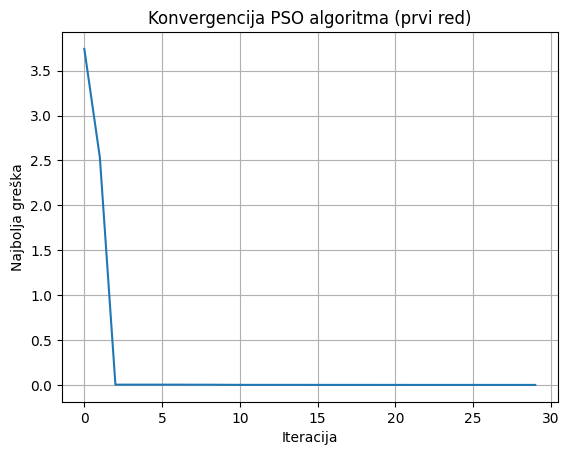

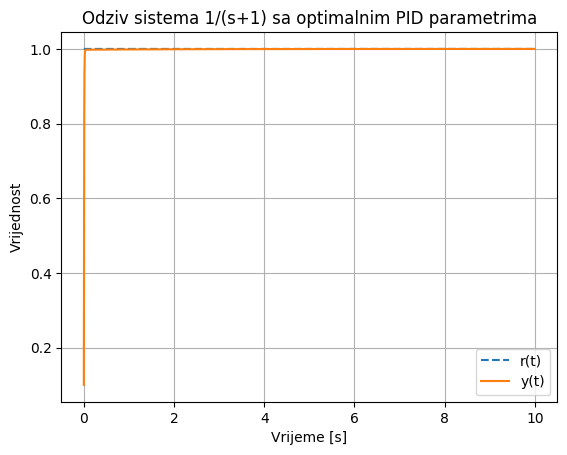

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

P = 15
I = 30

bounds = np.array([
    [0, 200],  # Kp
    [0, 200],  # Ki
    [0, 60],   # Kd
])

r_func = step_ref  # referenca

# 2) Pokreni PSO za prvi red
pid, best_score, best_scores_history1, found_it = run_pso(
    P, I, bounds,
    r_func=r_func,
    simulate_func=simulate_pid_first_order,
    seed=1
)

print("=== RE-RUN TEST (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={best_score:.6f}")
print(f"found_at_iteration={found_it}")

# 3) Graf konvergencije PSO
plt.figure()
plt.plot(best_scores_history1)
plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška")
plt.title("Konvergencija PSO algoritma (prvi red)")
plt.grid()
plt.show()

# 4) Odziv sistema + referenca (PRVI RED: y' = u - y)
dt = 0.001
T = 10.0
t_vals = np.arange(0, T, dt)

r_vals = np.array([r_func(t) for t in t_vals])

Kp, Ki, Kd = pid
y_list = []

y = 0.0
integral = 0.0
prev_error = 0.0

for t in t_vals:
    r = r_func(t)
    error = r - y

    integral += error * dt
    integral = np.clip(integral, -50, 50)

    derivative = (error - prev_error) / dt
    prev_error = error

    u = Kp * error + Ki * integral + Kd * derivative
    u = np.clip(u, -100, 100)

    # PRVI RED: y' = u - y
    y += (u - y) * dt

    y_list.append(y)

plt.figure()
plt.plot(t_vals, r_vals, "--", label="r(t)")
plt.plot(t_vals, y_list, label="y(t)")
plt.xlabel("Vrijeme [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv sistema 1/(s+1) sa optimalnim PID parametrima")
plt.legend()
plt.grid()
plt.show()


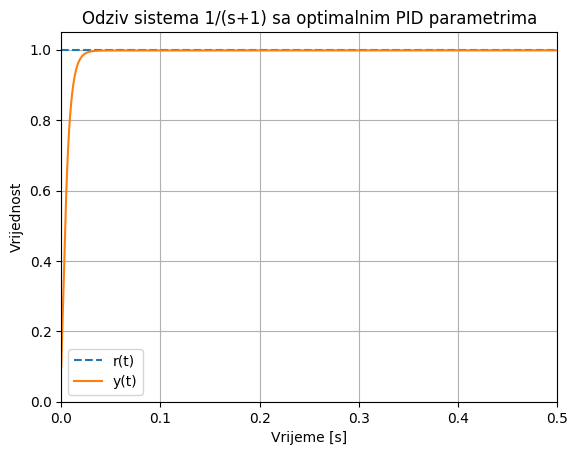

In [ ]:
plt.figure()
plt.plot(t_vals, r_vals, "--", label="r(t)")
plt.plot(t_vals, y_list, label="y(t)")
plt.xlim(0, 0.5)          # prikaži prvih 0.5 s (probaj i 0.2)
plt.ylim(0, 1.05)         # da se fino vidi približavanje
plt.xlabel("Vrijeme [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv sistema 1/(s+1) sa optimalnim PID parametrima")
plt.legend()
plt.grid()
plt.show()


##Testovi ramp

In [ ]:
r_func = ramp_ref


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 10],  # Kp
    [0, 10],  # Ki
    [0, 5],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=9.998744, Ki=9.999010, Kd=0.003976
  score=0.012124
  found_at_iteration=27

[TEST 2] particles=20, iterations=50
  Kp=9.999972, Ki=9.999995, Kd=0.000638
  score=0.012121
  found_at_iteration=47

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=9.999972, Ki=9.999995, Kd=0.000638
score=0.012121
found_at_iteration=47


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 100],  # Kp
    [0, 80],  # Ki
    [0, 60],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=99.997733, Ki=79.987717, Kd=0.837503
  score=0.000177
  found_at_iteration=28

[TEST 2] particles=20, iterations=50
  Kp=99.995448, Ki=79.999636, Kd=0.010430
  score=0.000176
  found_at_iteration=46

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=99.995448, Ki=79.999636, Kd=0.010430
score=0.000176
found_at_iteration=46


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 200],  # Kp
    [0, 200],  # Ki
    [0, 60],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=198.908572, Ki=198.812323, Kd=0.080984
  score=0.000032
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=199.971557, Ki=199.998717, Kd=0.070705
  score=0.000031
  found_at_iteration=47

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=199.971557, Ki=199.998717, Kd=0.070705
score=0.000031
found_at_iteration=47


###Najbolji rezultat

=== PSO (PRVI RED, RAMPA) ===
particles=20, iterations=50
Kp=199.995529, Ki=199.998566, Kd=0.173462
score=0.000031
found_at_iteration=49


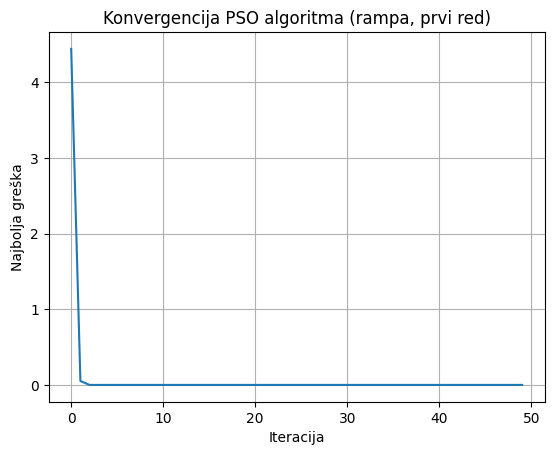

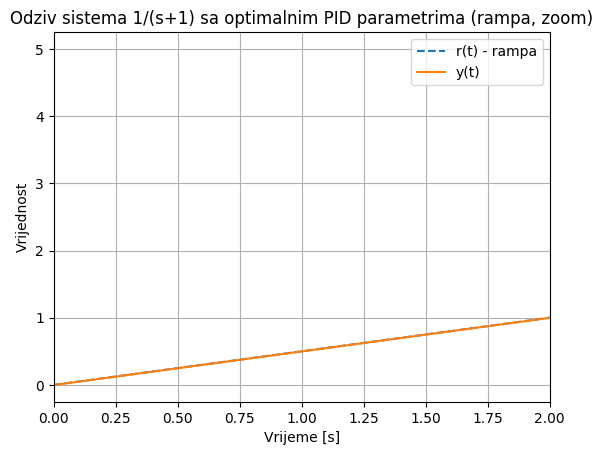

In [ ]:
# PSO test za rampu (prvi red)
P = 20
I = 50

bounds = np.array([
    [0, 200],  # Kp
    [0, 200],  # Ki
    [0, 60],   # Kd
])

best_pid, best_score, best_scores_history2, found_it = run_pso(
    P, I, bounds,
    r_func=ramp_ref,
    simulate_func=simulate_pid_first_order,
    seed=1
)

print("=== PSO (PRVI RED, RAMPA) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
print(f"score={best_score:.6f}")
print(f"found_at_iteration={found_it}")

# 1) Konvergencija PSO
plt.figure()
plt.plot(best_scores_history2)
plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška")
plt.title("Konvergencija PSO algoritma (rampa, prvi red)")
plt.grid()
plt.show()

# 2) Odziv + referenca (zoom)
dt = 0.001
T = 10.0
t_vals = np.arange(0, T, dt)
r_vals = np.array([ramp_ref(t) for t in t_vals])

Kp, Ki, Kd = best_pid
y_list = []
y = 0.0
integral = 0.0
prev_error = 0.0

for t, r in zip(t_vals, r_vals):
    error = r - y
    integral += error * dt
    integral = np.clip(integral, -50, 50)

    derivative = (error - prev_error) / dt
    prev_error = error

    u = Kp*error + Ki*integral + Kd*derivative
    u = np.clip(u, -100, 100)

    y += (u - y) * dt
    y_list.append(y)

plt.figure()
plt.plot(t_vals, r_vals, "--", label="r(t) - rampa")
plt.plot(t_vals, y_list, label="y(t)")
plt.xlim(0, 2.0)   # zoom
plt.xlabel("Vrijeme [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv sistema 1/(s+1) sa optimalnim PID parametrima (rampa, zoom)")
plt.legend()
plt.grid()
plt.show()


##Testovi sin

In [ ]:
r_func = sine_ref


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 10],  # Kp
    [0, 10],  # Ki
    [0, 5],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=9.998714, Ki=0.244891, Kd=0.993476
  score=0.159288
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=9.999625, Ki=0.000520, Kd=0.994714
  score=0.158451
  found_at_iteration=46

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=9.999625, Ki=0.000520, Kd=0.994714
score=0.158451
found_at_iteration=46


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 100],  # Kp
    [0, 80],  # Ki
    [0, 60],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=82.770259, Ki=32.735931, Kd=32.975621
  score=2.484622
  found_at_iteration=0

[TEST 2] particles=20, iterations=50
  Kp=26.161213, Ki=23.879291, Kd=48.853544
  score=2.484622
  found_at_iteration=0

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=15, iterations=30
Kp=82.770259, Ki=32.735931, Kd=32.975621
score=2.484622
found_at_iteration=0


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 200],  # Kp
    [0, 200],  # Ki
    [0, 60],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=165.540519, Ki=81.839827, Kd=32.975621
  score=2.484622
  found_at_iteration=0

[TEST 2] particles=20, iterations=50
  Kp=52.322427, Ki=59.698229, Kd=48.853544
  score=2.484622
  found_at_iteration=0

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=15, iterations=30
Kp=165.540519, Ki=81.839827, Kd=32.975621
score=2.484622
found_at_iteration=0


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 5],  # Kp
    [0, 5],  # Ki
    [0, 2],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=4.993408, Ki=0.019273, Kd=0.995737
  score=0.337995
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=4.998834, Ki=0.002345, Kd=0.997036
  score=0.337235
  found_at_iteration=49

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=4.998834, Ki=0.002345, Kd=0.997036
score=0.337235
found_at_iteration=49


In [ ]:
# 5 test kombinacija
configs = [
    (15, 30),
    (20, 50),
    (30, 60),
    (40, 80),
    (50, 100),
]

bounds = np.array([
    [0, 10],  # Kp
    [0, 10],  # Ki
    [0, 5],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=9.998714, Ki=0.244891, Kd=0.993476
  score=0.159288
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=9.999625, Ki=0.000520, Kd=0.994714
  score=0.158451
  found_at_iteration=46

[TEST 3] particles=30, iterations=60
  Kp=9.999998, Ki=0.000174, Kd=0.994687
  score=0.158442
  found_at_iteration=56

[TEST 4] particles=40, iterations=80
  Kp=10.000000, Ki=0.000000, Kd=0.994641
  score=0.158441
  found_at_iteration=78



###Najbolji rezultat

=== PSO (PRVI RED, SINUS) ===
particles=40, iterations=80
Kp=20.000000, Ki=0.000003, Kd=0.989350
score=0.054052
found_at_iteration=77


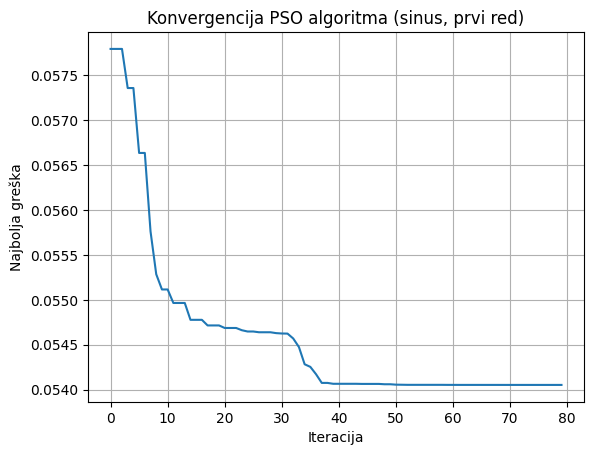

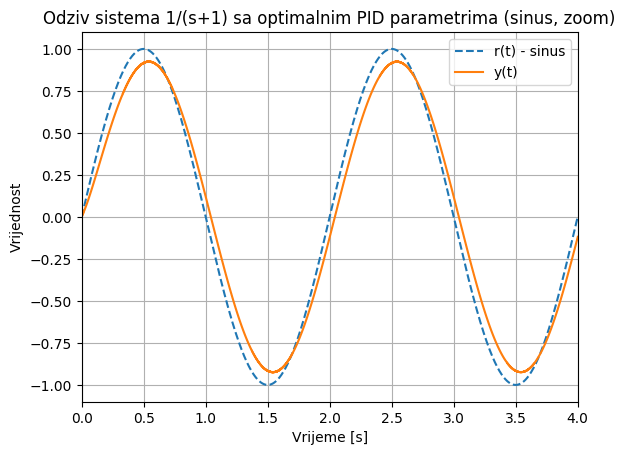

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

P = 40
I = 80

bounds = np.array([
    [0, 20],  # Kp
    [0, 10],  # Ki
    [0, 5],   # Kd
])

# --- Pokreni PSO za sine_ref (PRVI RED) ---
best_pid, best_score, best_scores_history3, found_it = run_pso(
    P, I, bounds,
    r_func=sine_ref,
    simulate_func=simulate_pid_first_order,
    seed=2
)

print("=== PSO (PRVI RED, SINUS) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
print(f"score={best_score:.6f}")
print(f"found_at_iteration={found_it}")

# --- (1) Graf konvergencije PSO ---
plt.figure()
plt.plot(best_scores_history3)
plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška")
plt.title("Konvergencija PSO algoritma (sinus, prvi red)")
plt.grid()
plt.show()

# --- (2) Odziv sistema + referenca (sinus), sa zoom-om ---
dt = 0.001
T = 10.0
t_vals = np.arange(0, T, dt)

r_vals = np.array([sine_ref(t) for t in t_vals])

Kp, Ki, Kd = best_pid
y_list = []

y = 0.0
integral = 0.0
prev_error = 0.0

for t, r in zip(t_vals, r_vals):
    error = r - y
    integral += error * dt
    integral = np.clip(integral, -50, 50)

    derivative = (error - prev_error) / dt
    prev_error = error

    u = Kp * error + Ki * integral + Kd * derivative
    u = np.clip(u, -100, 100)

    # PRVI RED: y' = u - y
    y += (u - y) * dt
    y_list.append(y)

plt.figure()
plt.plot(t_vals, r_vals, "--", label="r(t) - sinus")
plt.plot(t_vals, y_list, label="y(t)")
plt.xlim(0, 4.0)
plt.xlabel("Vrijeme [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv sistema 1/(s+1) sa optimalnim PID parametrima (sinus, zoom)")
plt.legend()
plt.grid()
plt.show()


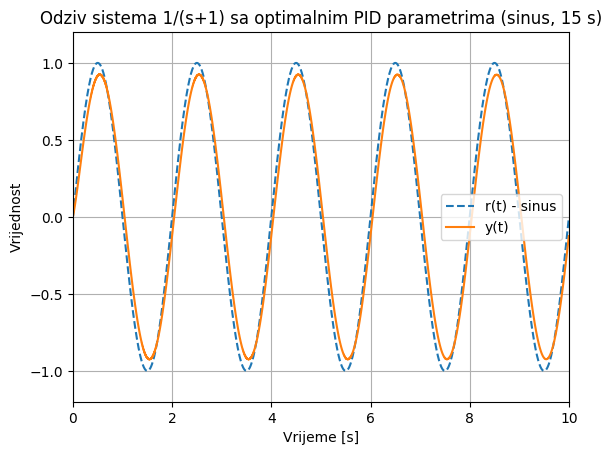

In [ ]:
# Odziv sistema + referenca (sinus), duže vrijeme
dt = 0.001
T = 10.0
t_vals = np.arange(0, T, dt)

r_vals = np.array([sine_ref(t) for t in t_vals])

Kp, Ki, Kd = best_pid
y_list = []

y = 0.0
integral = 0.0
prev_error = 0.0

for t, r in zip(t_vals, r_vals):
    error = r - y
    integral += error * dt
    integral = np.clip(integral, -50, 50)

    derivative = (error - prev_error) / dt
    prev_error = error

    u = Kp * error + Ki * integral + Kd * derivative
    u = np.clip(u, -100, 100)

    # PRVI RED: y' = u - y
    y += (u - y) * dt
    y_list.append(y)

plt.figure()
plt.plot(t_vals, r_vals, "--", label="r(t) - sinus")
plt.plot(t_vals, y_list, label="y(t)")
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
plt.xlabel("Vrijeme [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv sistema 1/(s+1) sa optimalnim PID parametrima (sinus, 15 s)")
plt.legend()
plt.grid()
plt.show()


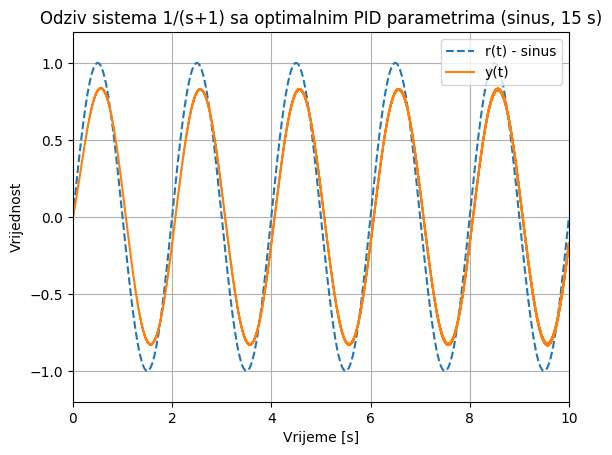

In [ ]:
# Odziv sistema + referenca (sinus), duže vrijeme
dt = 0.001
T = 10.0
t_vals = np.arange(0, T, dt)

r_vals = np.array([sine_ref(t) for t in t_vals])

Kp, Ki, Kd = best_pid
y_list = []

y = 0.0
integral = 0.0
prev_error = 0.0

for t, r in zip(t_vals, r_vals):
    error = r - y
    integral += error * dt
    integral = np.clip(integral, -50, 50)

    derivative = (error - prev_error) / dt
    prev_error = error

    u = Kp * error + Ki * integral + Kd * derivative
    u = np.clip(u, -100, 100)

    # PRVI RED: y' = u - y
    y += (u - y) * dt
    y_list.append(y)

plt.figure()
plt.plot(t_vals, r_vals, "--", label="r(t) - sinus")
plt.plot(t_vals, y_list, label="y(t)")
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
plt.xlabel("Vrijeme [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv sistema 1/(s+1) sa optimalnim PID parametrima (sinus, 15 s)")
plt.legend()
plt.grid()
plt.show()


##Konvergencija

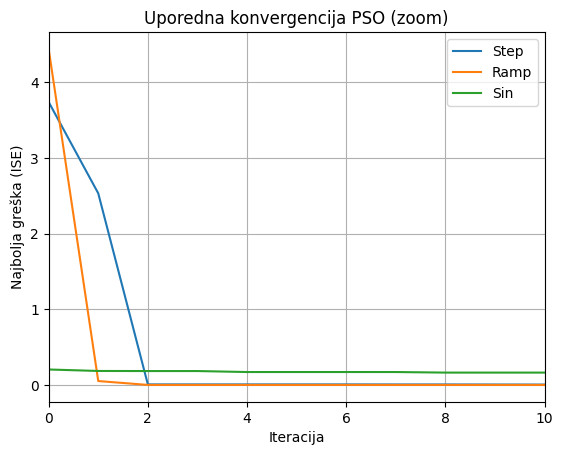

In [ ]:
plt.plot(best_scores_history1, label="Step")
plt.plot(best_scores_history2, label="Ramp")
plt.plot(best_scores_history3, label="Sin")

plt.xlim(0, 10)  # prvih 10 iteracija 5)
plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška (ISE)")
plt.title("Uporedna konvergencija PSO (zoom)")
plt.legend()
plt.grid()
plt.show()


[Step] Kp=9.996821, Ki=9.997189, Kd=0.090092, score=0.046474, found_at_iteration=49
[Rampa] Kp=9.999972, Ki=9.999995, Kd=0.000638, score=0.012121, found_at_iteration=47
[Sinus] Kp=9.999990, Ki=0.002584, Kd=0.994605, score=0.158449, found_at_iteration=47


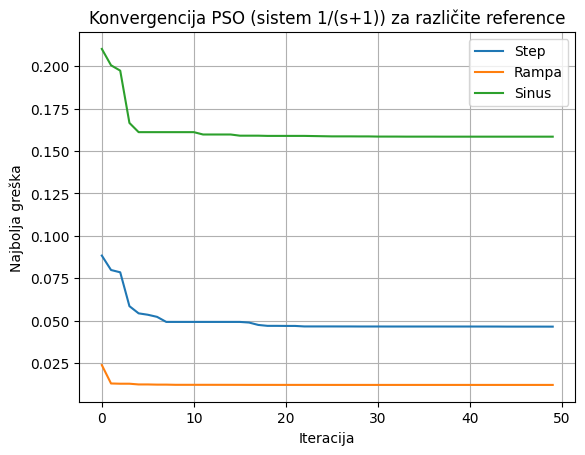

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- PSO postavke (isti za sve reference da poređenje bude fer) ---
P = 20
I = 50

bounds = np.array([
    [0, 10],  # Kp
    [0, 10],  # Ki
    [0, 5],   # Kd
])

refs = {
    "Step": step_ref,
    "Rampa": ramp_ref,
    "Sinus": sine_ref
}

histories = {}
best_params = {}

# --- Pokreni PSO za svaku referencu i sačuvaj historiju ---
for idx, (name, r_func) in enumerate(refs.items(), start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    histories[name] = hist
    best_params[name] = (best_pid, best_score, found_it)

    print(f"[{name}] Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}, "
          f"score={best_score:.6f}, found_at_iteration={found_it}")

# --- Jedan graf: konvergencija za Step / Rampu / Sinus ---
plt.figure()
for name, hist in histories.items():
    plt.plot(hist, label=name)

plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška")
plt.title("Konvergencija PSO (sistem 1/(s+1)) za različite reference")
plt.grid()
plt.legend()
plt.show()


[Step] Kp=199.879383, Ki=133.869796, Kd=0.000245, score=0.004001, found_at_iteration=49
[Rampa] Kp=199.971557, Ki=199.998717, Kd=0.070705, score=0.000031, found_at_iteration=47
[Sinus] Kp=199.882533, Ki=199.871302, Kd=0.076913, score=0.000615, found_at_iteration=47


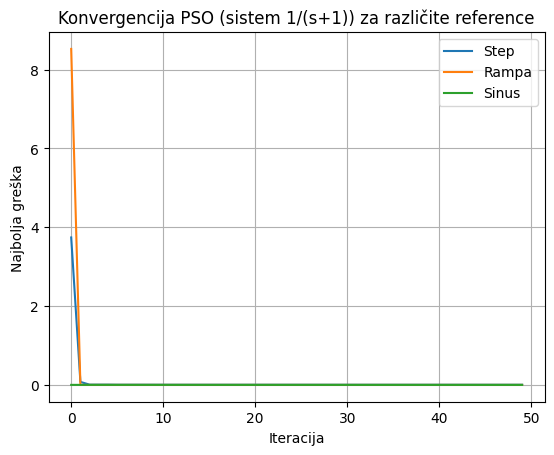

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- PSO postavke (isti za sve reference da poređenje bude fer) ---
P = 20
I = 50

bounds = np.array([
    [0, 200],  # Kp
    [0, 200],  # Ki
    [0, 60],   # Kd
])

refs = {
    "Step": step_ref,
    "Rampa": ramp_ref,
    "Sinus": sine_ref
}

histories = {}
best_params = {}

# --- Pokreni PSO za svaku referencu i sačuvaj historiju ---
for idx, (name, r_func) in enumerate(refs.items(), start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid_first_order,
        seed=idx
    )

    histories[name] = hist
    best_params[name] = (best_pid, best_score, found_it)

    print(f"[{name}] Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}, "
          f"score={best_score:.6f}, found_at_iteration={found_it}")

# --- Jedan graf: konvergencija za Step / Rampu / Sinus ---
plt.figure()
for name, hist in histories.items():
    plt.plot(hist, label=name)

plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška")
plt.title("Konvergencija PSO (sistem 1/(s+1)) za različite reference")
plt.grid()
plt.legend()
plt.show()


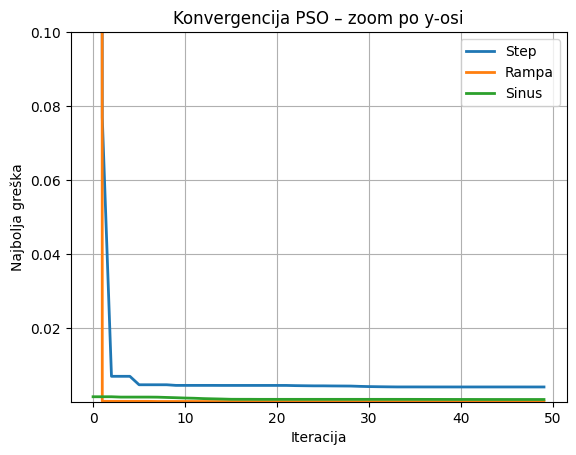

In [ ]:
plt.figure()
for name, hist in histories.items():
    plt.plot(hist, label=name, linewidth=2)

plt.ylim(1e-5, 1e-1)   # prilagodi po potrebi
plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška")
plt.title("Konvergencija PSO – zoom po y-osi")
plt.grid()
plt.legend()
plt.show()


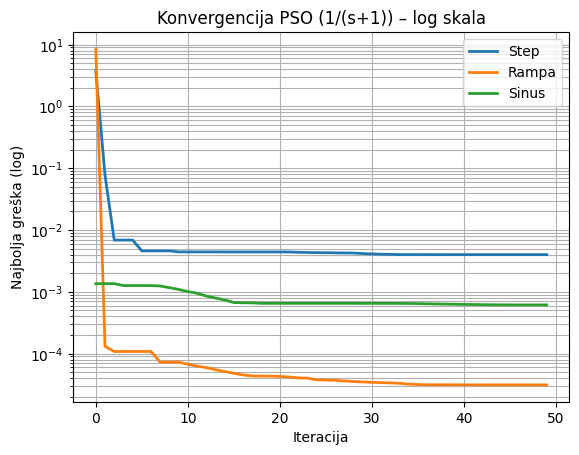

In [ ]:
plt.figure()
for name, hist in histories.items():
    plt.plot(hist, label=name, linewidth=2)

plt.yscale("log")
plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška (log)")
plt.title("Konvergencija PSO (1/(s+1)) – log skala")
plt.grid(True, which="both")
plt.legend()
plt.show()


#Model upravljanog sistema 2

Razmatra se linearni dinamički sistem drugog reda opisan prenosnom funkcijom:

G2(s) = 1 / (s² + 10s + 20)

Ovaj sistem predstavlja standardni primjer u teoriji upravljanja i
koristi se za analizu ponašanja regulatora.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


In [ ]:
# Definicija kontinuiranog sistema
num = [1]
den = [1, 10, 20]

system = signal.TransferFunction(num, den)

# Diskretizacija sistema
dt = 0.01
system_d = system.to_discrete(dt)


## Funkcija cilja
Kriterij optimizacije je integral kvadratne greške (ISE),
koji penalizira velika odstupanja sistema od željene vrijednosti.


In [ ]:
r_func = step_ref


In [ ]:
def simulate_pid(Kp, Ki, Kd, r_func, dt=0.001, T=5):
    n_steps = int(T/dt)
    y = 0          # trenutni izlaz
    y_dot = 0      # brzina promjene izlaza
    integral = 0
    prev_error = 0
    error_sum = 0
    r = 1  # referentni signal
    for k in range(n_steps):

        t = k * dt
        r = r_func(t)
        error = r - y                   # greška prema željenoj vrijednosti 1
        integral += error * dt           # integralni dio
        integral = np.clip(integral, -50, 50)

        derivative = (error - prev_error) / dt
        prev_error = error

        u = Kp * error + Ki * integral + Kd * derivative  # PID signal
        u = np.clip(u, -100, 100)  # u praksi uvijek postoji ograničenje upravljačkog signala

        # Diskretizacija drugog reda: y'' + 10 y' + 20 y = u
        y_ddot = u - 10*y_dot - 20*y
        y_dot += y_ddot * dt
        y += y_dot * dt

        if not np.isfinite(y) or not np.isfinite(y_dot) or abs(y) > 1e6:
            return 1e18

        if not np.isfinite(error):
            return 1e18

        error_sum += (error**2) * dt


    return error_sum



##Testovi step

In [ ]:
r_func = step_ref


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 10],   # Kp
    [0, 10],   # Ki
    [0, 5],   # Kd
])

all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(P, I, bounds, seed=idx)
    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")
    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall
print("=== NAJBOLJE OD SVIH TESTOVA ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=9.999543, Ki=9.998799, Kd=0.090549
  score=0.827918
  found_at_iteration=28

[TEST 2] particles=20, iterations=50
  Kp=9.999973, Ki=9.999983, Kd=0.089430
  score=0.827838
  found_at_iteration=49

=== NAJBOLJE OD SVIH TESTOVA ===
particles=20, iterations=50
Kp=9.999973, Ki=9.999983, Kd=0.089430
score=0.827838
found_at_iteration=49


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 60],   # Kp
    [0, 50],   # Ki
    [0, 40],   # Kd
])

all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(P, I, bounds, seed=idx)
    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")
    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall
print("=== NAJBOLJE OD SVIH TESTOVA ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=59.997782, Ki=49.979568, Kd=0.045713
  score=0.146049
  found_at_iteration=22

[TEST 2] particles=20, iterations=50
  Kp=59.998677, Ki=49.998911, Kd=0.040191
  score=0.146014
  found_at_iteration=48

=== NAJBOLJE OD SVIH TESTOVA ===
particles=20, iterations=50
Kp=59.998677, Ki=49.998911, Kd=0.040191
score=0.146014
found_at_iteration=48


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 100],   # Kp
    [0, 80],   # Ki
    [0, 60],   # Kd
])

all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(P, I, bounds, seed=idx)
    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")
    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall
print("=== NAJBOLJE OD SVIH TESTOVA ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=99.993555, Ki=79.981905, Kd=0.003566
  score=0.102477
  found_at_iteration=26

[TEST 2] particles=20, iterations=50
  Kp=99.999781, Ki=79.999633, Kd=0.002227
  score=0.102472
  found_at_iteration=48

=== NAJBOLJE OD SVIH TESTOVA ===
particles=20, iterations=50
Kp=99.999781, Ki=79.999633, Kd=0.002227
score=0.102472
found_at_iteration=48


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 150],   # Kp
    [0, 150],   # Ki
    [0, 60],   # Kd
])

all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(P, I, bounds, seed=idx)
    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")
    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall
print("=== NAJBOLJE OD SVIH TESTOVA ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=149.948033, Ki=148.963154, Kd=4.395371
  score=0.093001
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=149.999947, Ki=149.998658, Kd=4.493481
  score=0.092993
  found_at_iteration=48

=== NAJBOLJE OD SVIH TESTOVA ===
particles=20, iterations=50
Kp=149.999947, Ki=149.998658, Kd=4.493481
score=0.092993
found_at_iteration=48


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 200],   # Kp
    [0, 200],   # Ki
    [0, 60],   # Kd
])

all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(P, I, bounds, seed=idx)
    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")
    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall
print("=== NAJBOLJE OD SVIH TESTOVA ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=199.979341, Ki=159.260559, Kd=7.243512
  score=0.091613
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=199.999740, Ki=160.577838, Kd=7.253765
  score=0.091613
  found_at_iteration=48

=== NAJBOLJE OD SVIH TESTOVA ===
particles=20, iterations=50
Kp=199.999740, Ki=160.577838, Kd=7.253765
score=0.091613
found_at_iteration=48


In [ ]:
# 5 test kombinacija
configs = [
    (15, 30),
    (20, 50),
    (30, 60),
    (40, 80),
    (50, 100),
]

bounds = np.array([
    [0, 200],   # Kp
    [0, 200],   # Ki
    [0, 60],   # Kd
])

all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid,
        seed=idx
    )
    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")
    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall
print("=== NAJBOLJE OD SVIH TESTOVA ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=199.979341, Ki=159.260559, Kd=7.243512
  score=0.091613
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=199.999740, Ki=160.577838, Kd=7.253765
  score=0.091613
  found_at_iteration=48

[TEST 3] particles=30, iterations=60
  Kp=199.999990, Ki=160.561760, Kd=7.249573
  score=0.091613
  found_at_iteration=59

[TEST 4] particles=40, iterations=80
  Kp=200.000000, Ki=160.560614, Kd=7.249723
  score=0.091613
  found_at_iteration=79

[TEST 5] particles=50, iterations=100
  Kp=200.000000, Ki=160.559027, Kd=7.249669
  score=0.091613
  found_at_iteration=99

=== NAJBOLJE OD SVIH TESTOVA ===
particles=50, iterations=100
Kp=200.000000, Ki=160.559027, Kd=7.249669
score=0.091613
found_at_iteration=99


###Najbolji rezultat

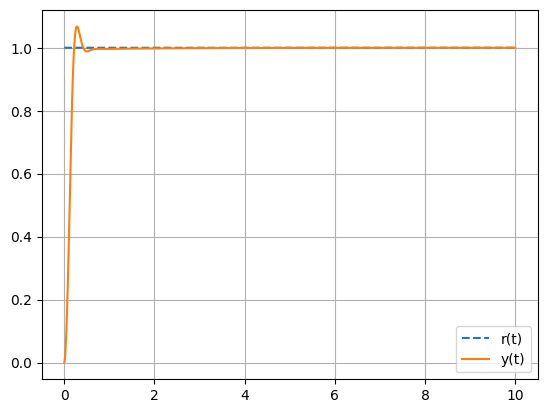

In [ ]:
t_vals = np.arange(0, 10, 0.001)
r_vals = np.array([step_ref(t) for t in t_vals])

# simulacija sa najboljim pid
Kp, Ki, Kd = pid
y_list = []
y_val, y_dot, integral, prev_error = 0, 0, 0, 0

for t in t_vals:
    r = step_ref(t)
    error = r - y_val
    integral += error * 0.001
    integral = np.clip(integral, -50, 50)

    derivative = (error - prev_error) / 0.001
    u = Kp*error + Ki*integral + Kd*derivative
    u = np.clip(u, -100, 100)

    y_ddot = u - 10*y_dot - 20*y_val
    y_dot += y_ddot * 0.001
    y_val += y_dot * 0.001

    y_list.append(y_val)
    prev_error = error

plt.plot(t_vals, r_vals, "--", label="r(t)")
plt.plot(t_vals, y_list, label="y(t)")
plt.legend(); plt.grid(); plt.show()


##Testovi ramp

In [ ]:
r_func = ramp_ref


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 10],  # Kp
    [0, 10],  # Ki
    [0, 5],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=9.997974, Ki=9.994275, Kd=1.345719
  score=1.910892
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=9.999886, Ki=9.999998, Kd=4.999992
  score=1.887379
  found_at_iteration=48

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=9.999886, Ki=9.999998, Kd=4.999992
score=1.887379
found_at_iteration=48


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 100],  # Kp
    [0, 80],  # Ki
    [0, 60],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=99.877840, Ki=79.979180, Kd=9.117602
  score=0.053683
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=99.999860, Ki=79.999968, Kd=0.000827
  score=0.053331
  found_at_iteration=49

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=99.999860, Ki=79.999968, Kd=0.000827
score=0.053331
found_at_iteration=49


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 200],  # Kp
    [0, 200],  # Ki
    [0, 60],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=199.944174, Ki=199.966443, Kd=26.355069
  score=0.010040
  found_at_iteration=29

[TEST 2] particles=20, iterations=50
  Kp=199.999459, Ki=199.999954, Kd=2.932300
  score=0.009957
  found_at_iteration=47

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=199.999459, Ki=199.999954, Kd=2.932300
score=0.009957
found_at_iteration=47


###Najbolji rezultat

=== PSO (DRUGI RED, RAMPA) ===
particles=20, iterations=50
Kp=199.998065, Ki=199.999975, Kd=2.889954
score=0.009957
found_at_iteration=42


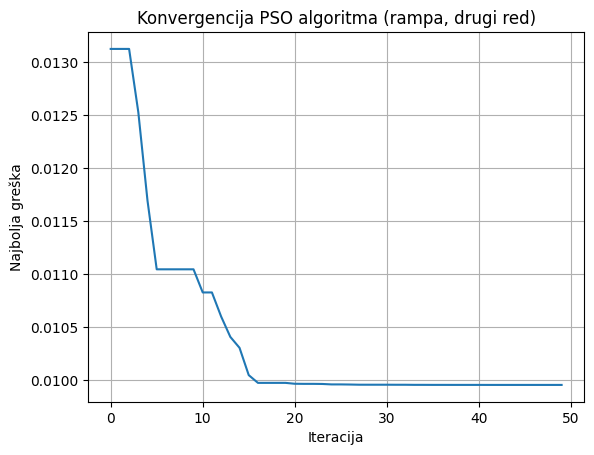

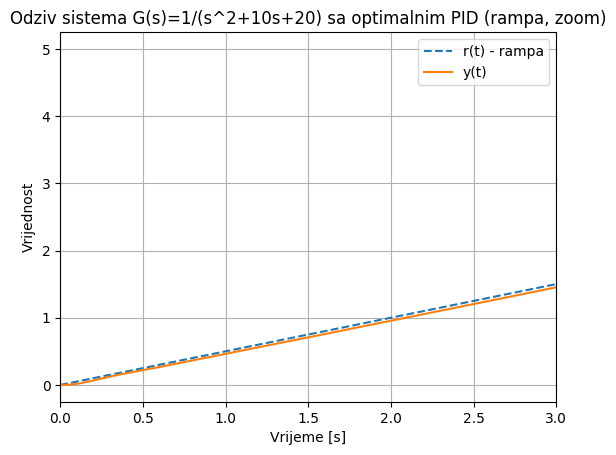

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

P = 20
I = 50

bounds = np.array([
    [0, 200],  # Kp
    [0, 200],  # Ki
    [0, 60],   # Kd
])

# --- pokreni PSO (DRUGI RED + RAMPA) ---
best_pid, best_score, best_scores_history, found_it = run_pso(
    P, I, bounds,
    r_func=ramp_ref,
    simulate_func=simulate_pid,
    seed=1
)

print("=== PSO (DRUGI RED, RAMPA) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
print(f"score={best_score:.6f}")
print(f"found_at_iteration={found_it}")

# --- (1) Konvergencija PSO ---
plt.figure()
plt.plot(best_scores_history)
plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška")
plt.title("Konvergencija PSO algoritma (rampa, drugi red)")
plt.grid()
plt.show()

# --- (2) Odziv sistema + referenca (DRUGI RED) ---
dt = 0.001
T = 10.0
t_vals = np.arange(0, T, dt)

r_vals = np.array([ramp_ref(t) for t in t_vals])

Kp, Ki, Kd = best_pid
y_list = []

y = 0.0
y_dot = 0.0
integral = 0.0
prev_error = 0.0

for t, r in zip(t_vals, r_vals):
    error = r - y
    integral += error * dt
    integral = np.clip(integral, -50, 50)

    derivative = (error - prev_error) / dt
    prev_error = error

    u = Kp * error + Ki * integral + Kd * derivative
    u = np.clip(u, -100, 100)

    # DRUGI RED: y'' + 10 y' + 20 y = u  ->  y'' = u - 10 y' - 20 y
    y_ddot = u - 10*y_dot - 20*y
    y_dot += y_ddot * dt
    y += y_dot * dt

    y_list.append(y)

plt.figure()
plt.plot(t_vals, r_vals, "--", label="r(t) - rampa")
plt.plot(t_vals, y_list, label="y(t)")

plt.xlim(0, 3.0)
plt.xlabel("Vrijeme [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv sistema G(s)=1/(s^2+10s+20) sa optimalnim PID (rampa, zoom)")
plt.legend()
plt.grid()
plt.show()


##Testovi sin

In [ ]:
r_func = sine_ref


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 10],  # Kp
    [0, 10],  # Ki
    [0, 5],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=9.996589, Ki=0.003815, Kd=4.999721
  score=1.044620
  found_at_iteration=28

[TEST 2] particles=20, iterations=50
  Kp=10.000000, Ki=0.000187, Kd=5.000000
  score=1.044496
  found_at_iteration=49

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=10.000000, Ki=0.000187, Kd=5.000000
score=1.044496
found_at_iteration=49


In [ ]:
configs = [
    (15, 30),
    (20, 50),
]

bounds = np.array([
    [0, 80],  # Kp
    [0, 60],  # Ki
    [0, 40],   # Kd
])


all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(
        P, I, bounds,
        r_func=r_func,
        simulate_func=simulate_pid,
        seed=idx
    )

    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")

    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall

print("=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=79.991855, Ki=0.030947, Kd=39.999330
  score=0.084699
  found_at_iteration=28

[TEST 2] particles=20, iterations=50
  Kp=79.999891, Ki=0.000261, Kd=39.999981
  score=0.084689
  found_at_iteration=48

=== NAJBOLJE OD SVIH TESTOVA (PRVI RED) ===
particles=20, iterations=50
Kp=79.999891, Ki=0.000261, Kd=39.999981
score=0.084689
found_at_iteration=48


###Najbolji rezultat

=== PSO (DRUGI RED, SINUS) ===
particles=20, iterations=50
Kp=79.999881, Ki=0.000563, Kd=39.999993
score=0.084689
found_at_iteration=48


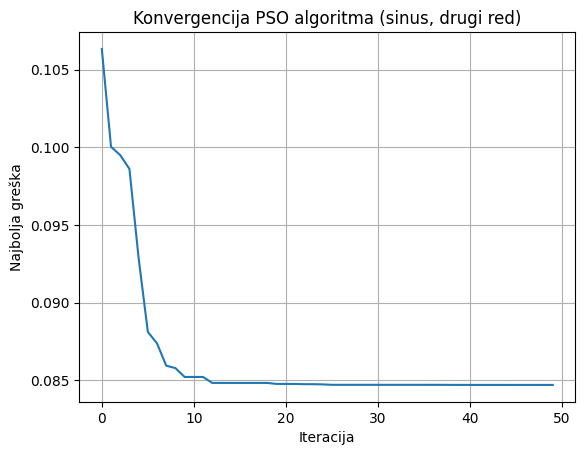

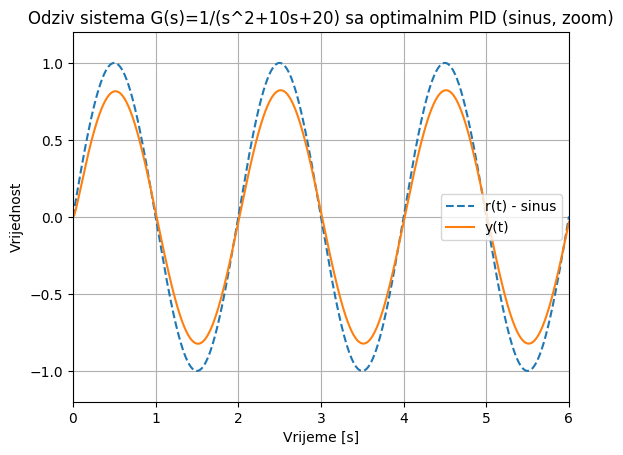

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- konfiguracija testa ---
P = 20
I = 50

bounds = np.array([
    [0, 80],   # Kp
    [0, 10],   # Ki
    [0, 40],   # Kd
])

best_pid, best_score, best_scores_history, found_it = run_pso(
    P, I, bounds,
    r_func=sine_ref,
    simulate_func=simulate_pid,
    seed=1
)

print("=== PSO (DRUGI RED, SINUS) ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
print(f"score={best_score:.6f}")
print(f"found_at_iteration={found_it}")

# --- (1) Konvergencija PSO ---
plt.figure()
plt.plot(best_scores_history)
plt.xlabel("Iteracija")
plt.ylabel("Najbolja greška")
plt.title("Konvergencija PSO algoritma (sinus, drugi red)")
plt.grid()
plt.show()

# --- (2) Odziv sistema + referenca (DRUGI RED) ---
dt = 0.001
T = 15.0
t_vals = np.arange(0, T, dt)

r_vals = np.array([sine_ref(t) for t in t_vals])

Kp, Ki, Kd = best_pid
y_list = []

y = 0.0
y_dot = 0.0
integral = 0.0
prev_error = 0.0

for t, r in zip(t_vals, r_vals):
    error = r - y
    integral += error * dt
    integral = np.clip(integral, -50, 50)

    derivative = (error - prev_error) / dt
    prev_error = error

    u = Kp * error + Ki * integral + Kd * derivative
    u = np.clip(u, -100, 100)

    # DRUGI RED: y'' = u - 10 y' - 20 y
    y_ddot = u - 10*y_dot - 20*y
    y_dot += y_ddot * dt
    y += y_dot * dt

    y_list.append(y)

plt.figure()
plt.plot(t_vals, r_vals, "--", label="r(t) - sinus")
plt.plot(t_vals, y_list, label="y(t)")
plt.xlim(0, 6.0)
plt.ylim(-1.2, 1.2)
plt.xlabel("Vrijeme [s]")
plt.ylabel("Vrijednost")
plt.title("Odziv sistema G(s)=1/(s^2+10s+20) sa optimalnim PID (sinus, zoom)")
plt.legend()
plt.grid()
plt.show()


##Testovi za PSO sa clipping-om


In [ ]:
# 5 test kombinacija
configs = [
    (15, 30),
    (20, 50),
    (30, 60),
    (40, 80),
    (50, 100),
]

# početni bounds (vidi dio 3 ispod kako ih "otkriti")
bounds = np.array([
    [0, 50],   # Kp
    [0, 30],   # Ki
    [0, 10],   # Kd
])

all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist = run_pso(P, I, bounds, seed=idx)
    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}\n")
    all_results.append((P, I, best_score, best_pid))

# ukupno najbolje među testovima
best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid = best_overall
print("=== NAJBOLJE OD SVIH TESTOVA ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")

[TEST 1] particles=15, iterations=30
  Kp=50.000000, Ki=30.000000, Kd=0.000000
  score=0.399287

[TEST 2] particles=20, iterations=50
  Kp=50.000000, Ki=30.000000, Kd=0.000000
  score=0.399287

[TEST 3] particles=30, iterations=60
  Kp=50.000000, Ki=30.000000, Kd=0.000000
  score=0.399287

[TEST 4] particles=40, iterations=80
  Kp=50.000000, Ki=30.000000, Kd=0.000000
  score=0.399287

[TEST 5] particles=50, iterations=100
  Kp=50.000000, Ki=30.000000, Kd=0.000000
  score=0.399287

=== NAJBOLJE OD SVIH TESTOVA ===
particles=15, iterations=30
Kp=50.000000, Ki=30.000000, Kd=0.000000
score=0.399287


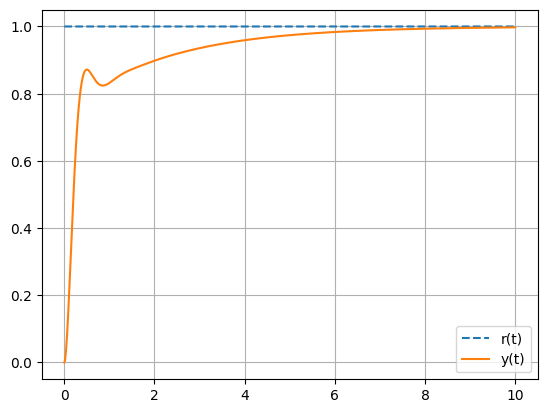

In [ ]:
t_vals = np.arange(0, 10, 0.001)
r_vals = np.array([step_ref(t) for t in t_vals])

# simulacija sa najboljim pid
Kp, Ki, Kd = pid
y_list = []
y_val, y_dot, integral, prev_error = 0, 0, 0, 0

for t in t_vals:
    r = step_ref(t)
    error = r - y_val
    integral += error * 0.001
    integral = np.clip(integral, -50, 50)

    derivative = (error - prev_error) / 0.001
    u = Kp*error + Ki*integral + Kd*derivative
    u = np.clip(u, -100, 100)

    y_ddot = u - 10*y_dot - 20*y_val
    y_dot += y_ddot * 0.001
    y_val += y_dot * 0.001

    y_list.append(y_val)
    prev_error = error

plt.plot(t_vals, r_vals, "--", label="r(t)")
plt.plot(t_vals, y_list, label="y(t)")
plt.legend(); plt.grid(); plt.show()


In [ ]:
# 5 test kombinacija
configs = [
    (15, 30),
    (20, 50),
    (30, 60),
    (40, 80),
    (50, 100),
]

# početni bounds (vidi dio 3 ispod kako ih "otkriti")
bounds = np.array([
    [0, 100],   # Kp
    [0, 80],   # Ki
    [0, 60],   # Kd
])

all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist = run_pso(P, I, bounds, seed=idx)
    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}\n")
    all_results.append((P, I, best_score, best_pid))

# ukupno najbolje među testovima
best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid = best_overall
print("=== NAJBOLJE OD SVIH TESTOVA ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")

[TEST 1] particles=15, iterations=30
  Kp=99.081852, Ki=79.363845, Kd=6.533542
  score=0.368457

[TEST 2] particles=20, iterations=50
  Kp=100.000000, Ki=59.173725, Kd=6.589487
  score=0.367592

[TEST 3] particles=30, iterations=60
  Kp=100.000000, Ki=59.173118, Kd=6.589510
  score=0.367592

[TEST 4] particles=40, iterations=80
  Kp=100.000000, Ki=59.172142, Kd=6.589561
  score=0.367592

[TEST 5] particles=50, iterations=100
  Kp=100.000000, Ki=59.172110, Kd=6.589561
  score=0.367592

=== NAJBOLJE OD SVIH TESTOVA ===
particles=50, iterations=100
Kp=100.000000, Ki=59.172110, Kd=6.589561
score=0.367592


stari simulate sa clipovima i error popravljenim

In [ ]:
# 5 test kombinacija
configs = [
    (15, 30),
    (20, 50),
    (30, 60),
    (40, 80),
    (50, 100),
]

# početni bounds (vidi dio 3 ispod kako ih "otkriti")
bounds = np.array([
    [0, 80],   # Kp
    [0, 60],   # Ki
    [0, 40],   # Kd
])

all_results = []
for idx, (P, I) in enumerate(configs, start=1):
    best_pid, best_score, hist, found_it = run_pso(P, I, bounds, seed=idx)
    print(f"[TEST {idx}] particles={P}, iterations={I}")
    print(f"  Kp={best_pid[0]:.6f}, Ki={best_pid[1]:.6f}, Kd={best_pid[2]:.6f}")
    print(f"  score={best_score:.6f}")
    print(f"  found_at_iteration={found_it}\n")
    all_results.append((P, I, best_score, best_pid, found_it))

best_overall = min(all_results, key=lambda x: x[2])
P, I, score, pid, found_it = best_overall
print("=== NAJBOLJE OD SVIH TESTOVA ===")
print(f"particles={P}, iterations={I}")
print(f"Kp={pid[0]:.6f}, Ki={pid[1]:.6f}, Kd={pid[2]:.6f}")
print(f"score={score:.6f}")
print(f"found_at_iteration={found_it}")


[TEST 1] particles=15, iterations=30
  Kp=80.000000, Ki=60.000000, Kd=0.000000
  score=0.120314
  found_at_iteration=1

[TEST 2] particles=20, iterations=50
  Kp=80.000000, Ki=60.000000, Kd=0.000000
  score=0.120314
  found_at_iteration=1

[TEST 3] particles=30, iterations=60
  Kp=80.000000, Ki=60.000000, Kd=0.000000
  score=0.120314
  found_at_iteration=1

[TEST 4] particles=40, iterations=80
  Kp=80.000000, Ki=60.000000, Kd=0.000000
  score=0.120314
  found_at_iteration=1

[TEST 5] particles=50, iterations=100
  Kp=80.000000, Ki=60.000000, Kd=0.000000
  score=0.120314
  found_at_iteration=0

=== NAJBOLJE OD SVIH TESTOVA ===
particles=15, iterations=30
Kp=80.000000, Ki=60.000000, Kd=0.000000
score=0.120314
found_at_iteration=1


#Optimalno upravljanje uz poremećaj

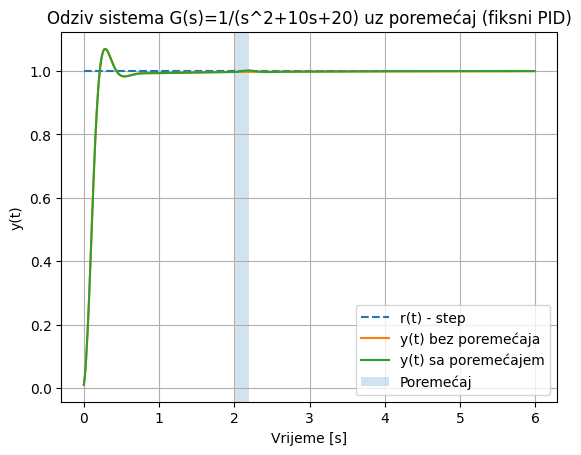

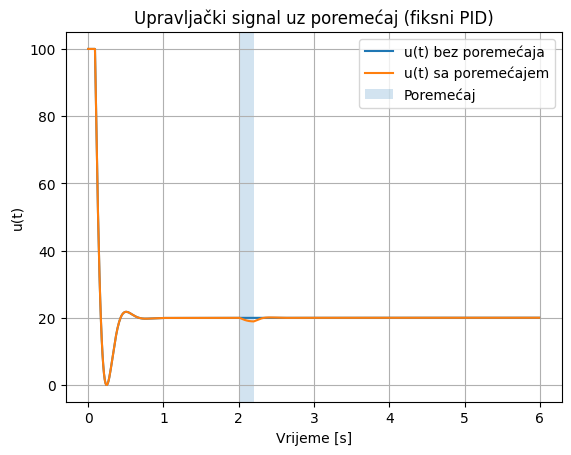

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- najbolji PID parametri  ---
Kp = 200.000000
Ki = 160.559027
Kd = 7.249669

# --- referenca ---
def step_ref(t):
    return 1.0

# --- poremećaj ---
def disturbance_func(t, t0=2.0, t1=2.2, amp=1.0):
    return amp if (t0 < t < t1) else 0.0


# =========================
# Odziv sistema (drugi red) - BEZ poremećaja (za plot)
# (ista logika kao u simulate_pid, samo vraća signale)
# =========================
def simulate_response_second_order_no_disturbance(Kp, Ki, Kd, r_func, dt=0.01, T=6.0,
                                                  u_max=100.0, int_max=50.0):
    t_vals = np.arange(0, T, dt)

    y = 0.0
    y_dot = 0.0
    integral = 0.0
    prev_error = 0.0

    y_list, r_list, u_list = [], [], []

    for t in t_vals:
        r = r_func(t)
        error = r - y

        integral += error * dt
        integral = np.clip(integral, -int_max, int_max)

        derivative = (error - prev_error) / dt
        prev_error = error

        u = Kp * error + Ki * integral + Kd * derivative
        u = np.clip(u, -u_max, u_max)

        # y'' = u - 10 y' - 20 y
        y_ddot = u - 10.0 * y_dot - 20.0 * y
        y_dot += y_ddot * dt
        y += y_dot * dt

        y_list.append(y)
        r_list.append(r)
        u_list.append(u)

    return t_vals, np.array(r_list), np.array(y_list), np.array(u_list)


# =========================
# Odziv sistema (drugi red) - SA poremećajem
# =========================
def simulate_response_second_order_disturbance(Kp, Ki, Kd, r_func, dt=0.01, T=6.0,
                                               u_max=100.0, int_max=50.0,
                                               t0=2.0, t1=2.2, amp=1.0):
    t_vals = np.arange(0, T, dt)

    y = 0.0
    y_dot = 0.0
    integral = 0.0
    prev_error = 0.0

    y_list, r_list, u_list, d_list = [], [], [], []

    for t in t_vals:
        r = r_func(t)
        error = r - y

        integral += error * dt
        integral = np.clip(integral, -int_max, int_max)

        derivative = (error - prev_error) / dt
        prev_error = error

        u = Kp * error + Ki * integral + Kd * derivative
        u = np.clip(u, -u_max, u_max)

        d = disturbance_func(t, t0=t0, t1=t1, amp=amp)

        # y'' = u + d - 10 y' - 20 y
        y_ddot = u + d - 10.0 * y_dot - 20.0 * y
        y_dot += y_ddot * dt
        y += y_dot * dt

        y_list.append(y)
        r_list.append(r)
        u_list.append(u)
        d_list.append(d)

    return t_vals, np.array(r_list), np.array(y_list), np.array(u_list), np.array(d_list)


# =========================
# Parametri simulacije
# =========================
dt = 0.01
T = 6.0
t0, t1, amp = 2.0, 2.2, 1.0

# --- simulacije ---
t_vals, r0, y0, u0 = simulate_response_second_order_no_disturbance(
    Kp, Ki, Kd, step_ref, dt=dt, T=T
)

t_vals, r1v, y1v, u1v, d1v = simulate_response_second_order_disturbance(
    Kp, Ki, Kd, step_ref, dt=dt, T=T, t0=t0, t1=t1, amp=amp
)

# =========================
# Plot: odziv + referenca
# =========================
plt.figure()
plt.plot(t_vals, r1v, "--", label="r(t) - step")
plt.plot(t_vals, y0, label="y(t) bez poremećaja")
plt.plot(t_vals, y1v, label="y(t) sa poremećajem")
plt.axvspan(t0, t1, alpha=0.2, label="Poremećaj")
plt.xlabel("Vrijeme [s]")
plt.ylabel("y(t)")
plt.title("Odziv sistema G(s)=1/(s^2+10s+20) uz poremećaj (fiksni PID)")
plt.legend()
plt.grid()
plt.show()

# =========================
# Plot: upravljački signal u(t)
# =========================
plt.figure()
plt.plot(t_vals, u0, label="u(t) bez poremećaja")
plt.plot(t_vals, u1v, label="u(t) sa poremećajem")
plt.axvspan(t0, t1, alpha=0.2, label="Poremećaj")
plt.xlabel("Vrijeme [s]")
plt.ylabel("u(t)")
plt.title("Upravljački signal uz poremećaj (fiksni PID)")
plt.legend()
plt.grid()
plt.show()


#///////////////////////